# Projeto Pipeline de dados-2025

# Storytelling: Pipeline de Dados com Telegram em parceria com a EBAC

# 1. Introdução
- **Objetivo do projeto:**

  Esse projeto tem como objetivo utilizar diversas ferramentas do AWS(Amazon Web Services) para coletar e armazenar mensagens de um grupo do Telegram com o uso de um chatbot.

  Tais ferramentas serão apresentadas mais adiante.

  **Nota:** O grupo no Telegram foi criado exclusivamente para este projeto, portanto, a quantidade de dados obtidos e analizados será pequenho, como forma de mostrar de forma mais focada os processos da criação de uma pipeline de dados do que os dados em sí.

- **Abordagem:** Os passos desse projeto;

  1- Chatbot no Telegram →  Um chatbot foi criado utilizando o botfather e adicionado a um grupo para capturar suas mensagens através de um token gerado e via HTTP POST.

  2- AWS API Gateway → Criação de um endpoint HTTP, Esse endpoint recebe mensagens do Telegram e encaminha para um AWS Lambda.

  3- AWS Lambda → O Lambda processa os dados, extrai informações e estrutura as mensagens, em seguida encaminha os dados para armazenamento no AWS S3.

  4- AWS S3 → Armazena  mensagens como arquivos JSON, CSV ou Parquet.

  5 - AWS EventBridge →  Tem a função de ativar diariamente a função de ETL do AWS Lambda, funcionando assim como um gatilho para repetir todo o precesso todos os dias.

  6- AWS Athena → Gera consultas SQL sobre os dados armazenados no S3.



# 2. Coleta de Dados


- **Origem dos dados:** Telegram.

###Mas o que é o telegram?

O Telegram é um aplicativo de mensagens instantâneas baseado na nuvem, conhecido por sua velocidade, segurança e funcionalidades avançadas, muito parecido com outro aplicativo utilizado, o WhatsApp.

- **Método de coleta:**

  O metodo de coleta usado é o Webhook, no qual o bot recebe mensagens automaticamente via HTTP POST(Proporcionado pelo AWS GateWay), utilizando um servidor AWS Lambda.

Após o lambda captar e fazer o devido tratamento aos dados, eles seguirão o padrão abaixo;


- **Exemplo de dados brutos coletados:**


{
    "update_id": 123,
    "message": {
        "message_id": 1,
        "from": {
            "id": 321,
            "is_bot": false,
            "first_name": "Lucas"
        },
        "chat": {
            "id": -789,
            "type": "group"
        },
        "date": 1640995200,
        "text": "Ola, pessoal!"
    }
}

# 3. Processamento dos Dados
  Nesta parte entraremos na etapa de ETL (Extract, Transform, Load) que é um processo essencial em engenharia de dados, que consiste em 3 passos;

  **1 - Extract;**

  Basicamente as mensagens do telegram serão coletadas pelo AWS GateWay.

  **2- Transform;**

  Em seguida o Lambda irá limpar, transformar  e converter os dados no formato correto para o armazenamento.

  **3 - Load;**

  Os dados serão armazenados em buckets no AWS S3.

Também será garantido o Armazenamento e particionamento dos dados.

### Mas o que é particionamento?

Particionar dados é uma técnica muito útil
para dividir volumes muito grandes de dados em partes menores e mais faceis de gerenciar,pois proporciona um desempenho maior, uma manutenção facilitada, além de otimizar muito o armazenamento, como será mostrado na parte de visualização mais a diante.

Dentro da Função Lambda, será Criado um código para processar os dados coletados.

- **Transformações aplicadas aos dados:**

Um laço de repetição será usado para varrer todas as chaves do arquivo e selecionar apenas as de interesse, Nesse caso apenas as mensagens. Se a mensagem não possuir a chave text, ela será criada com o valor igual a None. Além de adicionar duas chaves de tempo para indicar o momento em que o dado foi processado: context_date e context_timestamp.

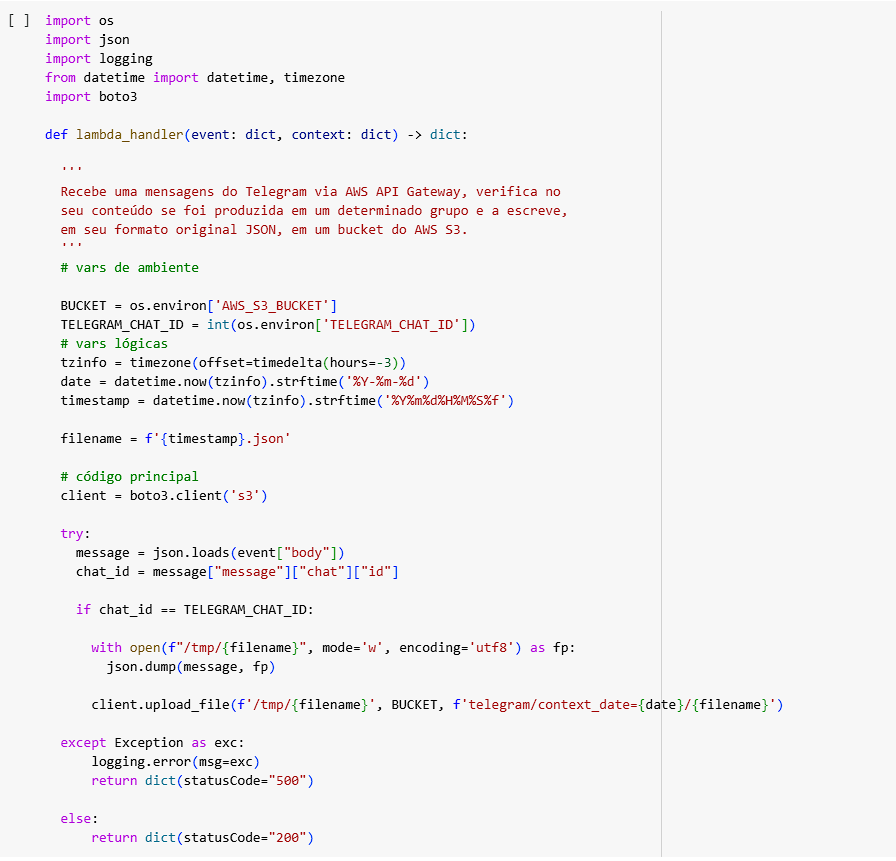

# 4. Armazenamento e Destino dos Dados


Os dados foram armazenados no AWS S3, que tem a função de passivamente armazenar as mensagens captadas pelo bot do Telegram no seu formato original: JSON. E para isso é criado um bucket, com o nome RAW.

### Portanto, todos os dados recolhidos do Telegram serão previamente processados pelo código acima e serão armazenados aqui.

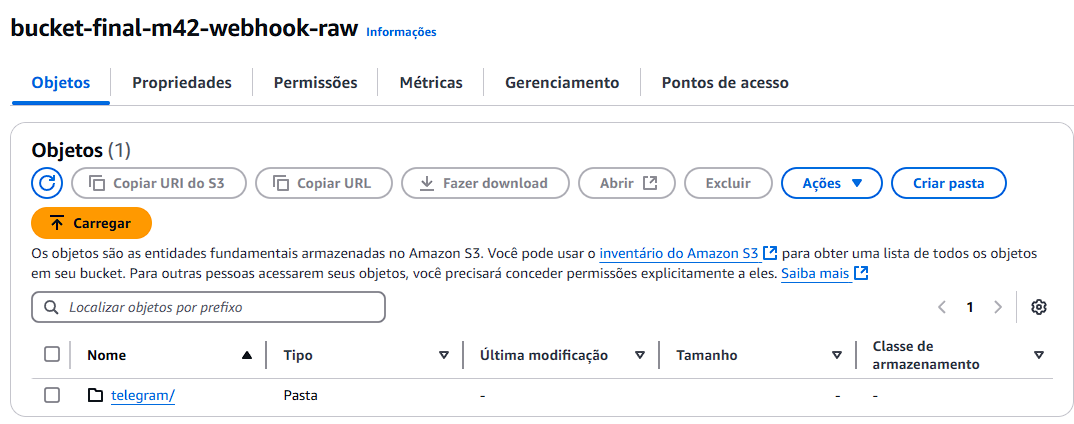

## Porém, teremos de retornar um pouco para a etapa de processamento dos dados, pois esse formato não é exatamente o ideal tendo em vista que serão feitas consultas em SQl no AWS Athena.

###Então, após a Função lambda armazenar no bucket RAW, será necessária outra função.

O AWS Lambda tem a função de ativamente processar as mensagens captadas pelo bot do **Telegram**, persistidas na camada cru no bucket do AWS S3, e persisti-las na camada enriquecida no AWS S3. Então uma função será criada, operando da seguinte forma:

 - Lista todos os arquivos JSON de uma única participação da camada crua de um bucket do AWS S3;
 - Para cada arquivo listado:
  - Faz o download do arquivo e carrega o conteúdo da mensagem;
  - Executa uma função de data wrangling;
  - Cria uma tabela do PyArrow e a contatena com as demais.
 - Persiste a tabela no formato Parquet na camada enriquecida em um bucket do AWS S3.

Código abaixo;

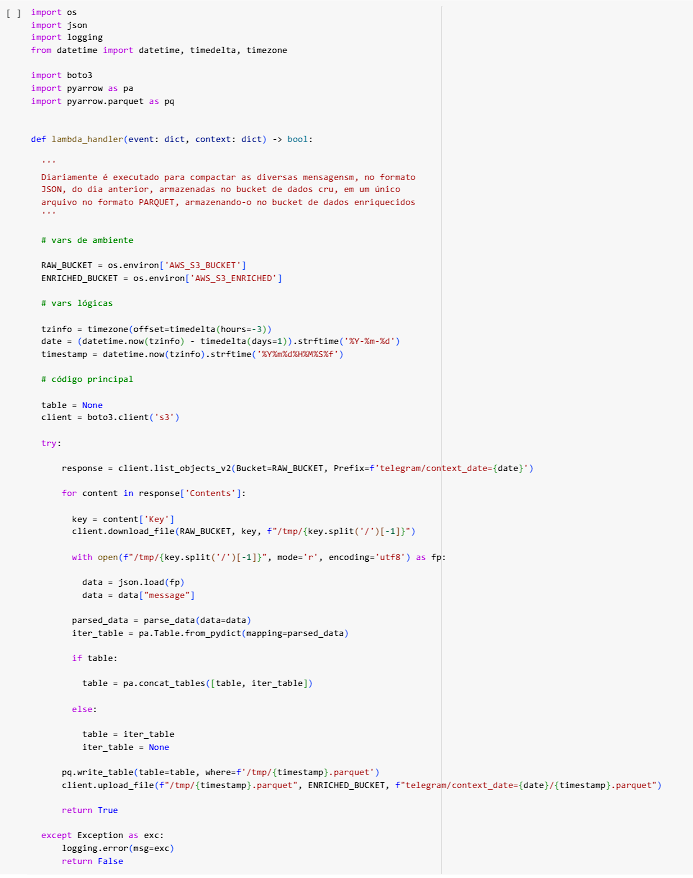

Data Wrangling;

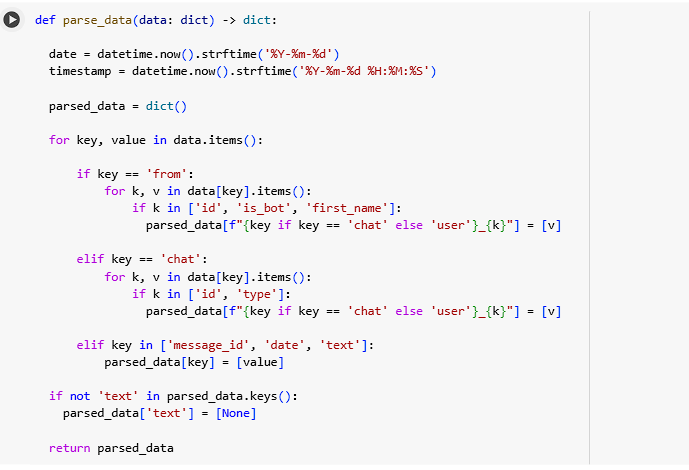

 O interessante é;

  O fato de utilizarmos duas camadas de armazenamento e processamento, permite o reprocessamento dos dados crus(RAW) de várias formas, diversas vezes se necessário.

Porém, para que a função funcione da forma correta, algumas configurações precisam ser realizadas.

**1- As variáveis de ambiente;**

O código exige a configuração de duas variáveis de ambiente: 'AWS_S3_BUCKET' e 'AWS_S3_ENRICHED' com os nomes dos buckets do `AWS S3` da camada Raw e Enriched, portanto, basta adicioná-las nas configurações do AWS Lambda.

**2- Permissões;**

É necessária a permissão de escrita nos buckets do S3 para a função do Lambda no AWS IAM.

**3- Camadas;**

Foi visto que o código da função utiliza o pacote Python PyArrow. Entretanto o ambiente padrão do Lambda não possui muitos pacotes instalados, então o PyArrow não será encontrado e apresentará erro. Então serão criadas camadas ou *layers*, onde podemos fazer o *upload* dos pacotes Python direto na plataforma ou através de um *bucket* do `AWS S3`.

Passos a seguir;

 - Criar um *bucket* no `AWS S3`;
 - Fazer o *upload* do código do pacote Python do PyArrow ( [link](https://github.com/awslabs/aws-data-wrangler/releases))
 - Criar *layer* e conectar na função.

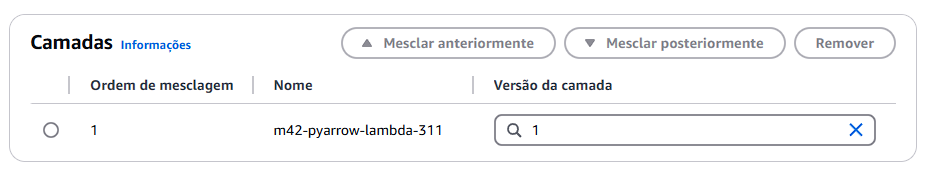

###Portanto, outro bucket será criado no S3 que terá o sufixo -Enriched.

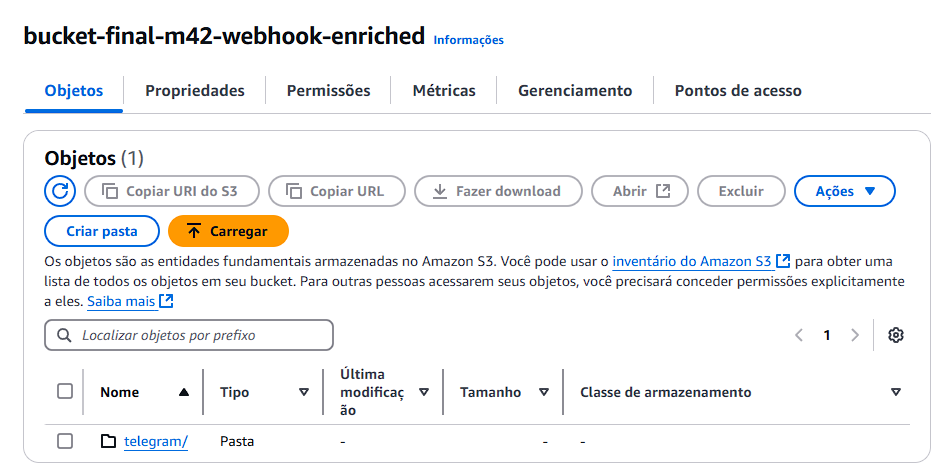

# 5. Consumo e Visualização dos Dados


###Agora utilizando o Athena, daremos uma olhada nos dados.


Primeiro é criada a tabela via query SQL, nomeada telegram.

```sql
CREATE EXTERNAL TABLE `telegram`(
  `message_id` bigint,
  `user_id` bigint,
  `user_is_bot` boolean,
  `user_first_name` string,
  `chat_id` bigint,
  `chat_type` string,
  `text` string,
  `date` bigint)
PARTITIONED BY (
  `context_date` date)
ROW FORMAT SERDE
  'org.apache.hadoop.hive.ql.io.parquet.serde.ParquetHiveSerDe'
STORED AS INPUTFORMAT
  'org.apache.hadoop.hive.ql.io.parquet.MapredParquetInputFormat'
OUTPUTFORMAT
  'org.apache.hadoop.hive.ql.io.parquet.MapredParquetOutputFormat'
LOCATION
  's3://<bucket-enriquecido>/'
```

Apenas criar a tabela não é o suficiente, para visualizar os dados é preciso também utilizar a seguinte query para carregar todas as partições de data.


```sql
MSCK REPAIR TABLE `telegram`;
```

Com as partições carregadas, hora de visualizar como ficaram os dados.


```sql
SELECT message_id
      ,user_id
      ,user_is_bot
      ,user_first_name
      ,chat_id
      ,chat_type
      ,date
      ,context_date
FROM "default"."telegram" limit 10;
```

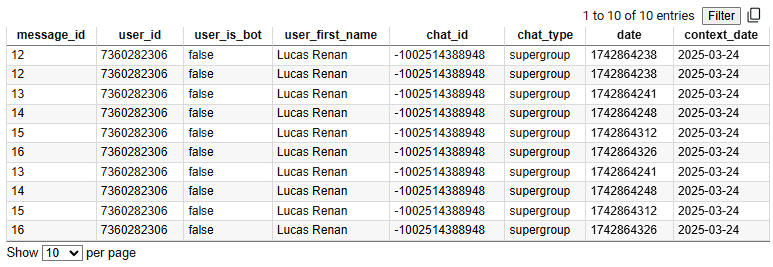

### Agora uma breve pergunta para ter um vislumbre do tipo de informações que podem ser obtidas.

**Qual a quantidade de mensagens por usuário por dia?**

```sql
SELECT
  context_date as data_mensagem,
  count(1) AS total_mensagens
FROM "telegram"
GROUP BY context_date
ORDER BY context_date DESC
```

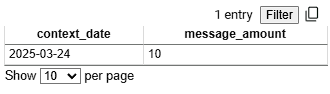

A consulta SQL retorna a data na qual as mensagens foram capturadas e a quantidade de mensagens.


# 6. Conclusão e Próximos Passos

###  Resultados alcançados

Este projeto demonstrou de forma prática como construir um pipeline de dados utilizando serviços da AWS em conjunto com a API do Telegram. Através da criação de um chatbot, foi possível capturar mensagens de um grupo no Telegram e enviá-las para um endpoint HTTP, gerenciado pelo API Gateway. As mensagens foram processadas e estruturadas por uma função Lambda e, em seguida, armazenadas no Amazon S3.

Com os dados devidamente organizados, foi possível realizar consultas SQL com o AWS Athena, extraindo informações, como a pergunta acima visa responder, além de possibilitar a criação de análises futuras de maneira simples e escalável.

**Nota:** O volume dos dados no momento da conclusão deste projeto ainda se mantem baixo.

###  Próximos passos

Desta forma, este pipeline pode ser mantido em funcionamento para continuar coletando dados diariamente, possibilitando análises temporais mais robustas conforme o volume de dados aumenta. Além disso, a estrutura já está pronta para receber mais tratamentos e visualizações,  se assim for requerido.

Este projeto cumpre o objetivo de ilustrar todas as etapas fundamentais de um pipeline de dados , desde a ingestão até a análise, utilizando tecnologias amplamente adotadas no mercado.
